# Import Dataset from Kaggle

In [ ]:
import kagglehub

# Download latest version of Carla Self Steering Dataset
self_steering_data_path = kagglehub.dataset_download("zahidbooni/alltownswithweather ")
print("Path to Carla Self Steering Dataset files:", self_steering_data_path)

# Download latest version of Carla Object Detection Dataset
object_detection_data_path = kagglehub.dataset_download("ibrahimalobaid/object-detection-carla-self-driving-car")
print("Path to Carla Object Detection Dataset files:", object_detection_data_path)

Using Colab cache for faster access to the 'alltownswithweather ' dataset.
Path to Carla Self Steering Dataset files: /kaggle/input/alltownswithweather 
Using Colab cache for faster access to the 'object-detection-carla-self-driving-car' dataset.
Path to Carla Object Detection Dataset files: /kaggle/input/object-detection-carla-self-driving-car


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Deep Learning Imports and Initialize to T4 Runtime

In [ ]:
import os
from pathlib import Path
import time
import shutil # Added import for shutil

# Deep Learning Imports
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, Dataset, random_split
import matplotlib.pyplot as plt

from PIL import Image

# Allow for T4 GPU compatibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0))

cuda
Tesla T4


# Display First Three Data in Dataset

In [ ]:

# @title
def display_first_n_images(directory_path, n=3):
    image_files = []
    for root, _, files in os.walk(directory_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                image_files.append(os.path.join(root, file))
                if len(image_files) >= n:
                    break
        if len(image_files) >= n:
            break

    if not image_files:
        print(f"No image files found in {directory_path} or its subdirectories.")
        return

    print(f"Displaying first {len(image_files)} images from {directory_path}:")
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(image_files):
        try:
            img = Image.open(img_path)
            plt.subplot(1, n, i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(img_path))
            plt.axis('off')
        except Exception as e:
            print(f"Could not open image {img_path}: {e}")
            plt.subplot(1, n, i + 1)
            plt.text(0.5, 0.5, 'Error loading image', horizontalalignment='center', verticalalignment='center')
            plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# @title
# # @title
# # # Common path for images in the self-steering dataset
# self_steering_images_dir = os.path.join(self_steering_data_path, 'testing_data') # Assuming images are in 'testing_data' subdirectory
# display_first_n_images(self_steering_images_dir)


Displaying first 3 images from /root/.cache/kagglehub/datasets/ibrahimalobaid/object-detection-carla-self-driving-car/versions/1/train/images:


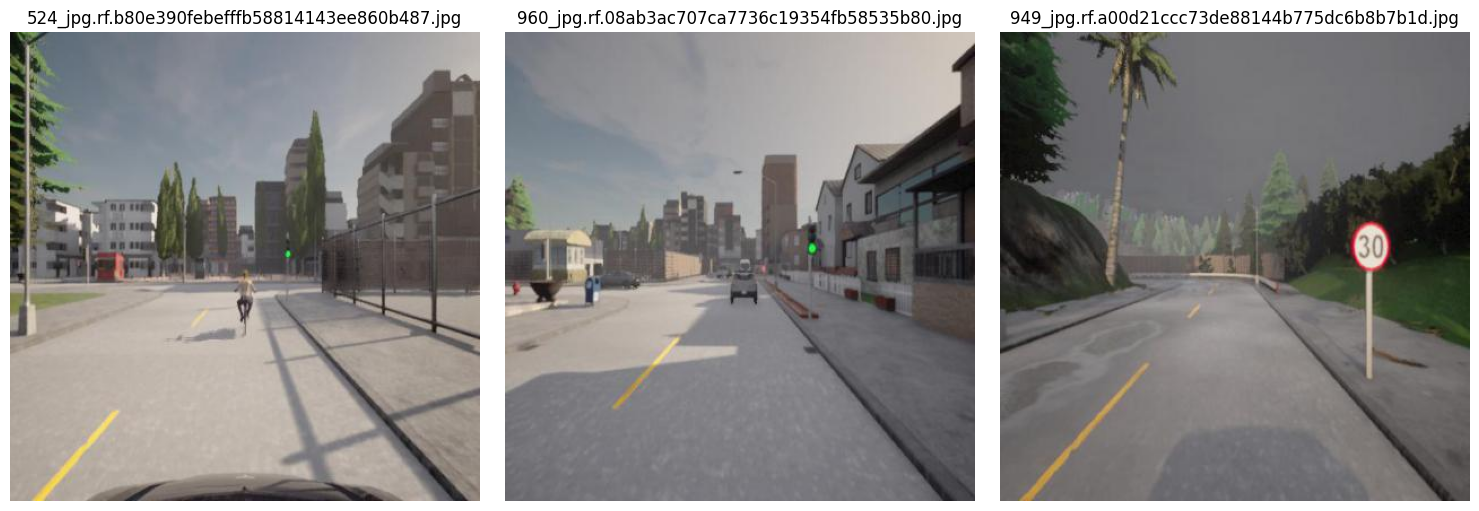

In [ ]:
# @title
# # Common path for images in object detection dataset
# # Trying 'train/images' as a common structure for object detection datasets
# object_detection_images_dir = os.path.join(object_detection_data_path, 'train', 'images')

# # If 'train/images' doesn't exist, try a different path like 'images'
# if not os.path.exists(object_detection_images_dir):
#     print(f"'{object_detection_images_dir}' not found, trying '{os.path.join(object_detection_data_path, 'images')}'...")
#     object_detection_images_dir = os.path.join(object_detection_data_path, 'images')

# display_first_n_images(object_detection_images_dir)

# NavisSteer Data Loader & Train Functions

In [ ]:
STEERING_CACHE_VERSION = 4
STEERING_FRAME_STRIDE = 4  # 1 uses every frame; 2 every second frame; etc.
STEERING_INPUT_MODE = "roi"  # "roi" uses roicropped/roicropped; "full" uses Data/Images
STEERING_SOURCE_IMAGE_SIZE = (220, 220)  # H, W before the lower-half ROI crop
STEERING_ROI_CROP = (0, 110, 220, 220)  # left, top, right, bottom in source pixels
_STEERING_DATASET_CACHE = {}
img_size = (110, 220)  # H, W of the existing ROI-cropped RGB images


class CachedSteeringDataset(Dataset):
    """Compact uint8 images with continuous steering-value targets."""

    def __init__(self, images_uint8, steering_values):
        if images_uint8.dtype != torch.uint8:
            raise TypeError("Cached images must use torch.uint8")
        if images_uint8.ndim != 4 or images_uint8.shape[1] != 3:
            raise ValueError(
                f"Expected cached images shaped [N, 3, H, W], got {images_uint8.shape}"
            )

        self.images_uint8 = images_uint8
        self.steering_values = steering_values.float().reshape(-1)

        if len(self.images_uint8) != len(self.steering_values):
            raise ValueError("Cached image and steering-value counts do not match")

    def __len__(self):
        return len(self.images_uint8)

    def __getitem__(self, index):
        # Keep samples as uint8. The training loop converts complete batches on GPU.
        return self.images_uint8[index], self.steering_values[index]


def _normalise_folder_name(name):
    return "".join(character.lower() for character in name if character.isalnum())


def _find_steering_images_dir(dataset_root, input_mode):
    dataset_root = Path(dataset_root)
    mode = str(input_mode).strip().lower()
    if mode not in {"roi", "full"}:
        raise ValueError("input_mode must be 'roi' or 'full'")

    candidates = (
        [
            dataset_root / "roicropped" / "roicropped",
            dataset_root / "roicropped",
        ]
        if mode == "roi"
        else [
            dataset_root / "Data" / "Images",
            dataset_root / "Data" / "images",
        ]
    )
    for candidate in candidates:
        if candidate.is_dir() and any(candidate.glob("image*.png")):
            return candidate

    expected_name = "roicropped" if mode == "roi" else "images"
    matches = [
        path
        for path in dataset_root.rglob("*")
        if (
            path.is_dir()
            and _normalise_folder_name(path.name) == expected_name
            and any(path.glob("image*.png"))
        )
    ]
    if len(matches) != 1:
        raise FileNotFoundError(
            f"Could not uniquely locate {mode!r} steering images under "
            f"{dataset_root}. Expected ROI images at "
            f"{dataset_root / 'roicropped' / 'roicropped'}."
        )
    return matches[0]


def _steering_source_files(
    dataset_root,
    frame_stride=1,
    input_mode=STEERING_INPUT_MODE,
):
    dataset_root = Path(dataset_root)
    images_dir = _find_steering_images_dir(dataset_root, input_mode)
    labels_path = dataset_root / "Data" / "SteerValues" / "steer_values.txt"

    if frame_stride < 1:
        raise ValueError("frame_stride must be at least 1")
    if not images_dir.is_dir():
        raise FileNotFoundError(f"Image directory not found: {images_dir}")
    if not labels_path.is_file():
        raise FileNotFoundError(f"Steering labels not found: {labels_path}")

    image_paths = sorted(
        images_dir.glob("image*.png"),
        key=lambda path: int("".join(filter(str.isdigit, path.stem))),
    )
    steering_values = torch.from_numpy(
        np.asarray(np.loadtxt(labels_path, dtype=np.float32), dtype=np.float32)
    ).reshape(-1)

    if len(image_paths) != len(steering_values):
        raise ValueError(
            f"Found {len(image_paths)} images but {len(steering_values)} steering values"
        )

    # Select matching image/label pairs before splitting. Both models reuse this.
    image_paths = image_paths[::frame_stride]
    steering_values = steering_values[::frame_stride].contiguous()
    return image_paths, steering_values


def _steering_cache_path(image_size, frame_stride, input_mode):
    height, width = map(int, image_size)

    drive_root = Path("/content/drive/MyDrive/NavisAI/cache")
    cache_root = (
        drive_root
        if Path("/content/drive/MyDrive").is_dir()
        else Path("/content/navisai_cache")
    )
    cache_root.mkdir(parents=True, exist_ok=True)
    return cache_root / (
        f"steering_{input_mode}_{height}x{width}_stride{frame_stride}_uint8_"
        f"v{STEERING_CACHE_VERSION}.pt"
    )


def _load_tensor_cache(cache_path, image_size, expected_count, input_mode):
    try:
        try:
            payload = torch.load(cache_path, map_location="cpu", weights_only=True)
        except TypeError:
            payload = torch.load(cache_path, map_location="cpu")

        images_uint8 = payload["images_uint8"]
        steering_values = payload["steering_values"]
        cached_size = tuple(payload["image_size"])
        cached_input_mode = payload.get("input_mode")

        if cached_input_mode != input_mode:
            raise ValueError(
                f"Cache input mode is {cached_input_mode!r}, not {input_mode!r}"
            )
        if cached_size != tuple(image_size):
            raise ValueError(f"Cache image size is {cached_size}, not {tuple(image_size)}")
        if len(images_uint8) != expected_count or len(steering_values) != expected_count:
            raise ValueError("Cache sample count does not match the selected source data")

        print(f"Loaded {expected_count:,} preprocessed steering images from {cache_path}")
        return CachedSteeringDataset(images_uint8, steering_values)
    except Exception as error:
        print(f"Ignoring invalid steering cache ({error}); rebuilding it once.")
        cache_path.unlink(missing_ok=True)
        return None


def prepare_steering_cache(
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    force_rebuild=False,
):
    """Build once, then reuse identical ROI frame/label pairs for both models."""

    image_size = tuple(map(int, image_size))
    frame_stride = int(frame_stride)
    input_mode = str(input_mode).strip().lower()
    if input_mode == "roi" and image_size != (110, 220):
        raise ValueError("ROI mode requires image_size=(110, 220)")
    memory_key = (
        str(Path(self_steering_data_path)),
        input_mode,
        image_size,
        frame_stride,
    )

    if not force_rebuild and memory_key in _STEERING_DATASET_CACHE:
        return _STEERING_DATASET_CACHE[memory_key]

    image_paths, steering_values = _steering_source_files(
        self_steering_data_path,
        frame_stride=frame_stride,
        input_mode=input_mode,
    )
    cache_path = _steering_cache_path(image_size, frame_stride, input_mode)

    if cache_path.is_file() and not force_rebuild:
        dataset = _load_tensor_cache(
            cache_path,
            image_size,
            len(image_paths),
            input_mode,
        )
        if dataset is not None:
            _STEERING_DATASET_CACHE[memory_key] = dataset
            return dataset

    height, width = image_size
    images_uint8 = torch.empty(
        (len(image_paths), 3, height, width),
        dtype=torch.uint8,
    )

    print(
        f"Preprocessing {len(image_paths):,} selected steering images once "
        f"(every {frame_stride} frame(s))."
    )
    started = time.time()

    for index, image_path in enumerate(image_paths):
        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image = image.resize((width, height), Image.Resampling.BILINEAR)
            images_uint8[index] = TF.pil_to_tensor(image)

        if (index + 1) % 5000 == 0 or index + 1 == len(image_paths):
            print(f"Cached {index + 1:,}/{len(image_paths):,} images")

    temporary_path = cache_path.with_suffix(cache_path.suffix + ".tmp")
    torch.save(
        {
            "cache_version": STEERING_CACHE_VERSION,
            "image_size": image_size,
            "frame_stride": frame_stride,
            "input_mode": input_mode,
            "source_image_size": STEERING_SOURCE_IMAGE_SIZE,
            "roi_crop": STEERING_ROI_CROP if input_mode == "roi" else None,
            "images_uint8": images_uint8,
            "steering_values": steering_values,
        },
        temporary_path,
    )
    os.replace(temporary_path, cache_path)

    elapsed = (time.time() - started) / 60
    size_mb = cache_path.stat().st_size / (1024 ** 2)
    print(
        f"Steering cache saved to {cache_path} "
        f"({size_mb:.1f} MiB, {elapsed:.2f} minutes)."
    )

    dataset = CachedSteeringDataset(images_uint8, steering_values)
    _STEERING_DATASET_CACHE[memory_key] = dataset
    return dataset


def get_stirdata_loader(
    batch_size,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    split_seed=1000,
):
    if not np.isclose(train_ratio + val_ratio + test_ratio, 1.0):
        raise ValueError("train_ratio + val_ratio + test_ratio must equal 1")

    dataset = prepare_steering_cache(
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
    )
    dataset_size = len(dataset)
    train_size = int(train_ratio * dataset_size)
    val_size = int(val_ratio * dataset_size)
    test_size = dataset_size - train_size - val_size

    split_generator = torch.Generator().manual_seed(split_seed)
    train_dataset, val_dataset, test_dataset = random_split(
        dataset,
        [train_size, val_size, test_size],
        generator=split_generator,
    )

    loader_options = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
    )
    if num_workers > 0:
        loader_options["persistent_workers"] = True
        loader_options["prefetch_factor"] = 2

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        generator=torch.Generator().manual_seed(split_seed),
        **loader_options,
    )
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

    print(
        f"Steering samples: train={train_size:,}, validation={val_size:,}, "
        f"test={test_size:,}; input_mode={input_mode}; "
        f"image_size={tuple(image_size)}; frame_stride={frame_stride}; "
        f"uint8 cache=True"
    )
    return train_loader, val_loader, test_loader

In [ ]:
def _new_grad_scaler(amp_enabled):
    # Supports both current and older PyTorch versions available in Colab.
    try:
        return torch.amp.GradScaler("cuda", enabled=amp_enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=amp_enabled)


def _steering_batch_to_device(images, steering_values):
    # Transfer compact uint8 first, then convert the complete batch on the GPU.
    images = images.to(device, non_blocking=True)
    images = images.float().div_(255.0)
    targets = steering_values.to(device, non_blocking=True).float().view(-1, 1)
    return images, targets


def stir_train(
    model,
    batch_size=128,
    learning_rate=0.001,
    num_epochs=10,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
    model_name="SteeringModel",
    checkpoint_stem="steering_model",
):
    """Shared MSE loop with GPU batch conversion and mixed precision."""

    train_loader, val_loader, test_loader = get_stirdata_loader(
        batch_size=batch_size,
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
        num_workers=num_workers,
    )

    train_losses = []
    val_losses = []
    criterion = nn.SmoothL1Loss(beta=0.05)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    checkpoint_root = (
        Path("/content/drive/MyDrive/NavisAI/models")
        if Path("/content/drive/MyDrive").is_dir()
        else Path("/content/navisai_checkpoints")
    )
    checkpoint_root.mkdir(parents=True, exist_ok=True)
    best_checkpoint_path = checkpoint_root / f"{checkpoint_stem}_best.pt"
    final_checkpoint_path = checkpoint_root / f"{checkpoint_stem}_final.pt"
    best_val_loss = float("inf")

    def save_checkpoint(path, epoch, validation_mse):
        temporary_path = path.with_suffix(path.suffix + ".tmp")
        torch.save(
            {
                "checkpoint_version": 2,
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "epoch": int(epoch),
                "validation_mse": float(validation_mse),
                "image_size": tuple(image_size),
                "input_height": int(image_size[0]),
                "input_width": int(image_size[1]),
                "input_channels": 3,
                "input_mode": str(input_mode),
                "source_image_size": tuple(STEERING_SOURCE_IMAGE_SIZE),
                "roi_crop": (
                    tuple(STEERING_ROI_CROP)
                    if str(input_mode).lower() == "roi"
                    else None
                ),
                "pixel_range": (0.0, 1.0),
                "frame_stride": int(frame_stride),
                "split_seed": 1000,
                "batch_size": int(batch_size),
                "learning_rate": float(learning_rate),
                "train_losses": list(train_losses),
                "val_losses": list(val_losses),
            },
            temporary_path,
        )
        os.replace(temporary_path, path)

    amp_enabled = bool(use_amp and device.type == "cuda")
    scaler = _new_grad_scaler(amp_enabled)
    print(f"Mixed precision enabled: {amp_enabled}")
    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_started = time.time()
        model.train()
        running_train_loss = 0.0
        train_total = 0

        for images, steering_values in train_loader:
            images, steering_values = _steering_batch_to_device(
                images, steering_values
            )
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)
                if predictions.shape != steering_values.shape:
                    raise ValueError(
                        f"Prediction shape {predictions.shape} does not match "
                        f"target shape {steering_values.shape}"
                    )
                loss = criterion(predictions, steering_values)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_train_loss += loss.detach().float().item() * images.size(0)
            train_total += images.size(0)

        average_train_loss = running_train_loss / max(train_total, 1)
        train_losses.append(average_train_loss)

        model.eval()
        running_val_loss = 0.0
        val_total = 0

        with torch.inference_mode():
            for images, steering_values in val_loader:
                images, steering_values = _steering_batch_to_device(
                    images, steering_values
                )
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=amp_enabled,
                ):
                    predictions = model(images)
                    loss = criterion(predictions, steering_values)

                running_val_loss += loss.float().item() * images.size(0)
                val_total += images.size(0)

        average_val_loss = running_val_loss / max(val_total, 1)
        val_losses.append(average_val_loss)
        scheduler.step(average_val_loss)
        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            save_checkpoint(
                best_checkpoint_path,
                epoch=epoch + 1,
                validation_mse=average_val_loss,
            )
            print(f"Saved new best checkpoint: {best_checkpoint_path}")
        epoch_seconds = time.time() - epoch_started

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"training MSE={average_train_loss:.6f} | "
            f"validation MSE={average_val_loss:.6f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | "
            f"time={epoch_seconds:.1f}s"
        )

    save_checkpoint(
        final_checkpoint_path,
        epoch=num_epochs,
        validation_mse=val_losses[-1],
    )
    try:
        best_payload = torch.load(
            best_checkpoint_path,
            map_location=device,
            weights_only=True,
        )
    except TypeError:
        best_payload = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(best_payload["model_state_dict"])
    print("Restored the best-validation weights for evaluation.")

    elapsed_minutes = (time.time() - start_time) / 60
    print(f"Training took {elapsed_minutes:.2f} minutes.")
    print(f"Best checkpoint: {best_checkpoint_path}")
    print(f"Final checkpoint: {final_checkpoint_path}")
    return train_losses, val_losses


def evaluate_steering_model(
    model,
    batch_size=128,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
):
    """Evaluate on the same deterministic selected-frame test split."""

    _, _, test_loader = get_stirdata_loader(
        batch_size=batch_size,
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
        num_workers=num_workers,
    )

    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    total = 0
    amp_enabled = bool(use_amp and device.type == "cuda")
    model.eval()

    with torch.inference_mode():
        for images, steering_values in test_loader:
            images, targets = _steering_batch_to_device(images, steering_values)
            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)
            errors = predictions.float() - targets.float()

            squared_error_sum += errors.square().sum().item()
            absolute_error_sum += errors.abs().sum().item()
            total += targets.numel()

    metrics = {
        "test_mse": squared_error_sum / max(total, 1),
        "test_mae": absolute_error_sum / max(total, 1),
    }
    print(
        f"Test MSE={metrics['test_mse']:.6f} | "
        f"Test MAE={metrics['test_mae']:.6f}"
    )
    return metrics


In [40]:
def steering_accuracy_report(
    model,
    model_name,
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
):
    """
    Evaluate a steering-regression model on the deterministic test split.

    Tolerance accuracy is the percentage of predictions whose absolute error
    is no greater than the specified steering tolerance.
    """

    _, _, test_loader = get_stirdata_loader(
        batch_size=batch_size,
        image_size=image_size,
        frame_stride=frame_stride,
        input_mode=input_mode,
        num_workers=num_workers,
    )

    squared_error_sum = 0.0
    absolute_error_sum = 0.0
    target_sum = 0.0
    target_squared_sum = 0.0

    within_005 = 0
    within_010 = 0
    total_predictions = 0

    amp_enabled = bool(use_amp and device.type == "cuda")
    model.eval()

    with torch.inference_mode():
        for images, steering_values in test_loader:
            images, targets = _steering_batch_to_device(
                images,
                steering_values,
            )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=amp_enabled,
            ):
                predictions = model(images)

            predictions = predictions.float().view(-1)
            targets = targets.float().view(-1)
            errors = predictions - targets
            absolute_errors = errors.abs()

            squared_error_sum += errors.square().sum().item()
            absolute_error_sum += absolute_errors.sum().item()

            target_sum += targets.sum().item()
            target_squared_sum += targets.square().sum().item()

            within_005 += (absolute_errors <= 0.05).sum().item()
            within_010 += (absolute_errors <= 0.10).sum().item()
            total_predictions += targets.numel()

    mse = squared_error_sum / max(total_predictions, 1)
    rmse = mse ** 0.5
    mae = absolute_error_sum / max(total_predictions, 1)

    # Total variation of the test-set steering targets.
    total_target_variation = (
        target_squared_sum
        - (target_sum ** 2 / max(total_predictions, 1))
    )

    r_squared = (
        1.0 - squared_error_sum / total_target_variation
        if total_target_variation > 0
        else float("nan")
    )

    accuracy_005 = 100.0 * within_005 / max(total_predictions, 1)
    accuracy_010 = 100.0 * within_010 / max(total_predictions, 1)

    results = {
        "model": model_name,
        "test_samples": total_predictions,
        "test_mse": mse,
        "test_rmse": rmse,
        "test_mae": mae,
        "r_squared": r_squared,
        "accuracy_within_0.05": accuracy_005,
        "accuracy_within_0.10": accuracy_010,
    }

    print(f"\n{model_name} test-set performance")
    print("-" * 45)
    print(f"Test samples:              {total_predictions:,}")
    print(f"MSE:                       {mse:.6f}")
    print(f"RMSE:                      {rmse:.6f}")
    print(f"MAE:                       {mae:.6f}")
    print(f"R²:                        {r_squared:.4f}")
    print(f"Accuracy within ±0.05:     {accuracy_005:.2f}%")
    print(f"Accuracy within ±0.10:     {accuracy_010:.2f}%")

    return results

In [ ]:
# Build or load the shared steering-image cache before either model trains.
# The first run preprocesses the PNG files once; later runs load one compact tensor file.
shared_steering_dataset = prepare_steering_cache(image_size=img_size)
print(f"Shared cached steering samples: {len(shared_steering_dataset):,}")


Preprocessing 21,623 selected steering images once (every 4 frame(s)).
Cached 5,000/21,623 images
Cached 10,000/21,623 images
Cached 15,000/21,623 images
Cached 20,000/21,623 images
Cached 21,623/21,623 images
Steering cache saved to /content/drive/MyDrive/NavisAI/cache/steering_roi_110x220_stride4_uint8_v4.pt (1497.2 MiB, 1.58 minutes).
Shared cached steering samples: 21,623


# NavisVision Data Loader & Train Functions

In [ ]:
CLASS_NAMES = (
    "bike", "motobike", "person", "traffic_light_green",
    "traffic_light_orange", "traffic_light_red", "traffic_sign_30",
    "traffic_sign_60", "traffic_sign_90", "vehicle",
)

class YoloDetectionDataset(Dataset):
    """Read images and matching YOLO .txt labels without class folders."""

    IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

    def __init__(self, image_dir, label_dir, image_size=224):
        self.image_dir = Path(image_dir)
        self.label_dir = Path(label_dir)
        self.image_size = image_size
        self.classes = CLASS_NAMES

        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image directory not found: {self.image_dir}")
        if not self.label_dir.is_dir():
            raise FileNotFoundError(f"Label directory not found: {self.label_dir}")

        self.images = sorted(
            path for path in self.image_dir.iterdir()
            if path.suffix.lower() in self.IMAGE_EXTENSIONS
        )
        if not self.images:
            raise FileNotFoundError(f"No images found in {self.image_dir}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image_path = self.images[index]
        label_path = self.label_dir / f"{image_path.stem}.txt"

        image = Image.open(image_path).convert("RGB")
        image = TF.resize(image, [self.image_size, self.image_size])
        image = TF.to_tensor(image)

        annotations = []
        if label_path.exists():
            with label_path.open() as label_file:
                for line_number, line in enumerate(label_file, start=1):
                    values = line.strip().split()
                    if not values:
                        continue
                    if len(values) != 5:
                        raise ValueError(
                            f"{label_path}:{line_number} must contain "
                            "class_id center_x center_y width height"
                        )

                    class_id, cx, cy, width, height = map(float, values)
                    class_id = int(class_id)
                    if not 0 <= class_id < len(CLASS_NAMES):
                        raise ValueError(f"Invalid class id {class_id} in {label_path}")
                    if not all(0.0 <= value <= 1.0 for value in (cx, cy, width, height)):
                        raise ValueError(f"Non-normalized YOLO box in {label_path}")

                    annotations.append([class_id, cx, cy, width, height])

        targets = (
            torch.tensor(annotations, dtype=torch.float32)
            if annotations
            else torch.empty((0, 5), dtype=torch.float32)
        )
        return image, targets


def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return torch.stack(images), list(targets)


def get_objdata_loader(batch_size, image_size=224, num_workers=2):
    root = Path(object_detection_data_path)

    def make_dataset(split_names):
        for split_name in split_names:
            split_root = root / split_name
            if (split_root / "images").is_dir() and (split_root / "labels").is_dir():
                return YoloDetectionDataset(
                    split_root / "images",
                    split_root / "labels",
                    image_size=image_size,
                )
        raise FileNotFoundError(
            f"Could not find images/ and labels/ for any of {split_names} under {root}"
        )

    train_dataset = make_dataset(("train",))
    val_dataset = make_dataset(("valid", "val", "validation"))

    try:
        test_dataset = make_dataset(("test",))
    except FileNotFoundError:
        print("No test split found; using validation split as test split.")
        test_dataset = val_dataset

    loader_options = dict(
        batch_size=batch_size,
        num_workers=num_workers,
        pin_memory=(device.type == "cuda"),
        collate_fn=detection_collate_fn,
    )
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_options)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)

    print(
        f"Detection images: train={len(train_dataset)}, "
        f"validation={len(val_dataset)}, test={len(test_dataset)}"
    )
    return train_loader, val_loader, test_loader, CLASS_NAMES


In [ ]:
def build_yolo_targets(target_list, grid_size, num_classes, target_device):
    """Convert variable-length YOLO labels into one dense target per grid cell."""

    batch_size = len(target_list)
    dense = torch.zeros(
        batch_size, grid_size, grid_size, 5 + num_classes,
        device=target_device,
    )

    for batch_index, boxes in enumerate(target_list):
        for box in boxes.to(target_device):
            class_id = int(box[0].item())
            cx, cy, width, height = box[1:].clamp(0.0, 1.0)

            grid_x = min(int(cx.item() * grid_size), grid_size - 1)
            grid_y = min(int(cy.item() * grid_size), grid_size - 1)

            # One prediction per cell. If two objects share a cell, keep the larger.
            new_area = width * height
            old_area = dense[batch_index, grid_y, grid_x, 2:4].prod()
            if dense[batch_index, grid_y, grid_x, 4] == 1 and new_area <= old_area:
                continue

            dense[batch_index, grid_y, grid_x, 0] = cx * grid_size - grid_x
            dense[batch_index, grid_y, grid_x, 1] = cy * grid_size - grid_y
            dense[batch_index, grid_y, grid_x, 2] = width
            dense[batch_index, grid_y, grid_x, 3] = height
            dense[batch_index, grid_y, grid_x, 4] = 1.0
            dense[batch_index, grid_y, grid_x, 5:] = 0.0
            dense[batch_index, grid_y, grid_x, 5 + class_id] = 1.0

    return dense


class YoloDetectionLoss(nn.Module):
    """YOLO-style box, objectness, and class loss for one box per grid cell."""

    def __init__(self, box_weight=5.0, no_object_weight=0.1):
        super().__init__()
        self.box_weight = box_weight
        self.no_object_weight = no_object_weight

    def forward(self, predictions, targets):
        object_mask = targets[..., 4] == 1
        no_object_mask = ~object_mask

        objectness = F.binary_cross_entropy_with_logits(
            predictions[..., 4][object_mask],
            targets[..., 4][object_mask],
            reduction="mean",
        ) if object_mask.any() else predictions[..., 4].sum() * 0.0

        no_objectness = F.binary_cross_entropy_with_logits(
            predictions[..., 4][no_object_mask],
            targets[..., 4][no_object_mask],
            reduction="mean",
        ) if no_object_mask.any() else predictions[..., 4].sum() * 0.0

        if object_mask.any():
            predicted_xy = predictions[..., 0:2][object_mask].sigmoid()
            predicted_wh = predictions[..., 2:4][object_mask].sigmoid()
            target_xy = targets[..., 0:2][object_mask]
            target_wh = targets[..., 2:4][object_mask]

            xy_loss = F.smooth_l1_loss(predicted_xy, target_xy)
            wh_loss = F.smooth_l1_loss(
                torch.sqrt(predicted_wh.clamp_min(1e-6)),
                torch.sqrt(target_wh.clamp_min(1e-6)),
            )
            box_loss = xy_loss + wh_loss

            class_indices = targets[..., 5:][object_mask].argmax(dim=-1)
            class_loss = F.cross_entropy(
                predictions[..., 5:][object_mask],
                class_indices,
            )
        else:
            box_loss = predictions[..., :4].sum() * 0.0
            class_loss = predictions[..., 5:].sum() * 0.0

        total = (
            self.box_weight * box_loss
            + objectness
            + self.no_object_weight * no_objectness
            + class_loss
        )

        components = {
            "box": box_loss.detach(),
            "object": objectness.detach(),
            "no_object": no_objectness.detach(),
            "class": class_loss.detach(),
        }
        return total, components


In [ ]:
def obj_train(
    model,
    batch_size=16,
    learning_rate=0.001,
    num_epochs=15,
    image_size=224,
):
    """Train NavisVision with this notebook's own PyTorch training loop."""

    train_loader, val_loader, test_loader, classes = get_objdata_loader(
        batch_size=batch_size,
        image_size=image_size,
    )

    criterion = YoloDetectionLoss(box_weight=5.0, no_object_weight=0.1)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
    )

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        train_examples = 0

        for images, target_list in train_loader:
            images = images.to(device, non_blocking=True)
            targets = build_yolo_targets(
                target_list,
                grid_size=model.grid_size,
                num_classes=model.num_classes,
                target_device=device,
            )

            optimizer.zero_grad(set_to_none=True)
            predictions = model(images)
            loss, components = criterion(predictions, targets)

            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite training loss: {loss.item()}")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            train_examples += images.size(0)

        average_train_loss = running_train_loss / max(train_examples, 1)
        train_losses.append(average_train_loss)

        model.eval()
        running_val_loss = 0.0
        val_examples = 0

        with torch.no_grad():
            for images, target_list in val_loader:
                images = images.to(device, non_blocking=True)
                targets = build_yolo_targets(
                    target_list,
                    grid_size=model.grid_size,
                    num_classes=model.num_classes,
                    target_device=device,
                )

                predictions = model(images)
                loss, _ = criterion(predictions, targets)

                running_val_loss += loss.item() * images.size(0)
                val_examples += images.size(0)

        average_val_loss = running_val_loss / max(val_examples, 1)
        val_losses.append(average_val_loss)
        scheduler.step(average_val_loss)

        if average_val_loss < best_val_loss:
            best_val_loss = average_val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "classes": classes,
                    "grid_size": model.grid_size,
                    "image_size": image_size,
                    "validation_loss": best_val_loss,
                },
                "/content/navisvision_yolo_best.pt",
            )

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train={average_train_loss:.4f} | "
            f"validation={average_val_loss:.4f} | "
            f"lr={current_lr:.2e}"
        )

    elapsed_minutes = (time.time() - start_time) / 60
    print(f"Training took {elapsed_minutes:.2f} minutes.")
    print("Best checkpoint: /content/navisvision_yolo_best.pt")

    return train_losses, val_losses


# NavisSteer Model

In [ ]:
class NavisSteer(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.2)
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, X):
        X = self.pool(F.relu(self.conv1(X)))
        X = self.dropout(X)

        X = self.pool(F.relu(self.conv2(X)))
        X = self.dropout(X)

        X = self.pool(F.relu(self.conv3(X)))
        X = self.dropout(X)

        X = self.global_pool(X)
        X = X.view(X.size(0), -1)

        X = F.relu(self.fc1(X))
        X = self.dropout(X)
        X = self.fc2(X)

        return X

Steering samples: train=15,136, validation=3,243, test=3,244; input_mode=roi; image_size=(110, 220); frame_stride=4; uint8 cache=True
Mixed precision enabled: True
Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/navissteer_best.pt
Epoch 01/80 | training MSE=0.031844 | validation MSE=0.024678 | lr=1.00e-03 | time=7.8s
Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/navissteer_best.pt
Epoch 02/80 | training MSE=0.024912 | validation MSE=0.024226 | lr=1.00e-03 | time=7.3s
Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/navissteer_best.pt
Epoch 03/80 | training MSE=0.024272 | validation MSE=0.023451 | lr=1.00e-03 | time=7.4s
Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/navissteer_best.pt
Epoch 04/80 | training MSE=0.022821 | validation MSE=0.020236 | lr=1.00e-03 | time=7.4s
Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/navissteer_best.pt
Epoch 05/80 | training MSE=0.020943 | validation MSE=0.019201 | 

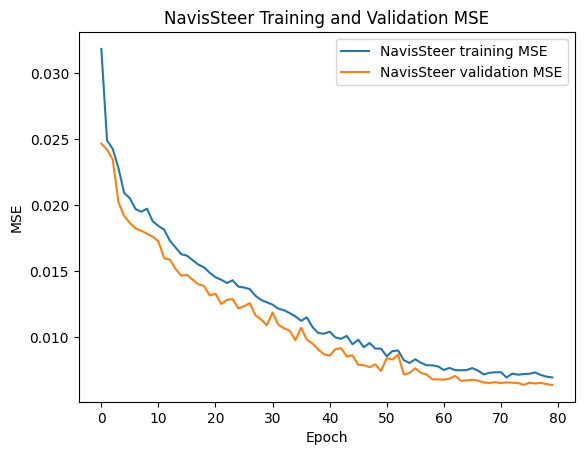

In [ ]:
# Train and evaluate NavisSteer on the same data/split as LinearSteer
navissteer_model = NavisSteer().to(device)

navissteer_train_losses, navissteer_val_losses = stir_train(
    navissteer_model,
    batch_size=256,
    learning_rate=0.001,
    num_epochs=80,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
    model_name="NavisSteer",
    checkpoint_stem="navissteer",
)

navissteer_metrics = evaluate_steering_model(
    navissteer_model,
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
)

print(
    "NavisSteer trainable parameters:",
    sum(parameter.numel() for parameter in navissteer_model.parameters()
        if parameter.requires_grad),
)

plt.plot(navissteer_train_losses, label="NavisSteer training MSE")
plt.plot(navissteer_val_losses, label="NavisSteer validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("NavisSteer Training and Validation MSE")
plt.legend()
plt.show()


In [42]:
navissteer_accuracy = steering_accuracy_report(
    navissteer_model,
    model_name="NavisSteer CNN",
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
)

Steering samples: train=15,136, validation=3,243, test=3,244; input_mode=roi; image_size=(110, 220); frame_stride=4; uint8 cache=True

NavisSteer CNN test-set performance
---------------------------------------------
Test samples:              3,244
MSE:                       0.001484
RMSE:                      0.038521
MAE:                       0.014518
R²:                        0.8227
Accuracy within ±0.05:     93.28%
Accuracy within ±0.10:     97.16%


# NavisVision Model

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(input_channels, output_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(output_channels),
            nn.LeakyReLU(0.1, inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, inputs):
        return self.block(inputs)


class NavisVision(nn.Module):
    """Small anchor-free YOLO-style detector with one box per grid cell."""

    def __init__(self, num_classes=len(CLASS_NAMES), grid_size=7):
        super().__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size

        self.backbone = nn.Sequential(
            ConvBlock(3, 32),       # 224 -> 112
            ConvBlock(32, 64),      # 112 -> 56
            ConvBlock(64, 128),     # 56 -> 28
            ConvBlock(128, 192),    # 28 -> 14
            ConvBlock(192, 256),    # 14 -> 7
        )
        self.grid_pool = nn.AdaptiveAvgPool2d((grid_size, grid_size))
        self.detection_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout2d(0.15),
            nn.Conv2d(256, 5 + num_classes, 1),
        )

    def forward(self, images):
        features = self.backbone(images)
        features = self.grid_pool(features)
        predictions = self.detection_head(features)

        # [batch, channels, grid_y, grid_x]
        # -> [batch, grid_y, grid_x, 5 + classes]
        return predictions.permute(0, 2, 3, 1).contiguous()


In [ ]:
# One-batch validation of the custom YOLO data/model/loss pipeline
smoke_train_loader, _, _, _ = get_objdata_loader(
    batch_size=2,
    image_size=224,
    num_workers=0,
)
smoke_images, smoke_target_list = next(iter(smoke_train_loader))
smoke_model = NavisVision(num_classes=len(CLASS_NAMES), grid_size=7).to(device)

with torch.no_grad():
    smoke_predictions = smoke_model(smoke_images.to(device))
    smoke_targets = build_yolo_targets(
        smoke_target_list,
        grid_size=smoke_model.grid_size,
        num_classes=smoke_model.num_classes,
        target_device=device,
    )
    smoke_loss, smoke_components = YoloDetectionLoss()(
        smoke_predictions,
        smoke_targets,
    )

print("images:", tuple(smoke_images.shape))
print("predictions:", tuple(smoke_predictions.shape))
print("targets:", tuple(smoke_targets.shape))
print("objects in batch:", int(smoke_targets[..., 4].sum().item()))
print("finite loss:", bool(torch.isfinite(smoke_loss)), float(smoke_loss))
print("components:", {name: float(value) for name, value in smoke_components.items()})

del smoke_model, smoke_predictions, smoke_targets
torch.cuda.empty_cache()


Detection images: train=1120, validation=320, test=160
images: (2, 3, 224, 224)
predictions: (2, 7, 7, 15)
targets: (2, 7, 7, 15)
objects in batch: 5
finite loss: True 3.969048500061035
components: {'box': 0.14412347972393036, 'object': 0.7471246123313904, 'no_object': 0.6579409241676331, 'class': 2.4355125427246094}


Detection images: train=1120, validation=320, test=160
Epoch 01/30 | train=2.0444 | validation=4.6282 | lr=1.00e-03
Epoch 02/30 | train=1.0674 | validation=0.9948 | lr=1.00e-03
Epoch 03/30 | train=0.6946 | validation=0.9443 | lr=1.00e-03
Epoch 04/30 | train=0.5057 | validation=0.5621 | lr=1.00e-03
Epoch 05/30 | train=0.3829 | validation=0.6898 | lr=1.00e-03
Epoch 06/30 | train=0.3562 | validation=0.5142 | lr=1.00e-03
Epoch 07/30 | train=0.2454 | validation=0.5201 | lr=1.00e-03
Epoch 08/30 | train=0.1849 | validation=0.3886 | lr=1.00e-03
Epoch 09/30 | train=0.1603 | validation=0.4686 | lr=1.00e-03
Epoch 10/30 | train=0.1500 | validation=0.4333 | lr=1.00e-03
Epoch 11/30 | train=0.1277 | validation=0.4610 | lr=5.00e-04
Epoch 12/30 | train=0.0909 | validation=0.3530 | lr=5.00e-04
Epoch 13/30 | train=0.0696 | validation=0.3713 | lr=5.00e-04
Epoch 14/30 | train=0.0606 | validation=0.3601 | lr=5.00e-04
Epoch 15/30 | train=0.0553 | validation=0.3519 | lr=5.00e-04
Epoch 16/30 | train=0.0514 | v

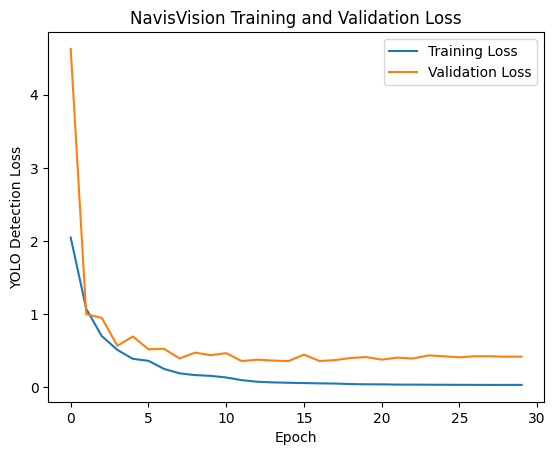

In [ ]:
# Train the custom NavisVision YOLO-style detector
model = NavisVision(
    num_classes=len(CLASS_NAMES),
    grid_size=7,
).to(device)

train_losses, val_losses = obj_train(
    model,
    batch_size=32,
    learning_rate=0.001,
    num_epochs=30,
    image_size=224,
)

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("YOLO Detection Loss")
plt.title("NavisVision Training and Validation Loss")
plt.legend()
plt.show()


# Baseline Model

In [ ]:
class LinearSteer(nn.Module):
    """Linear-regression baseline operating on flattened RGB ROI images."""

    def __init__(self, width=220, height=110):
        super().__init__()
        self.width = int(width)
        self.height = int(height)
        self.flatten = nn.Flatten(start_dim=1)
        self.linear = nn.Linear(3 * self.width * self.height, 1)

    def forward(self, images):
        flattened_images = self.flatten(images)
        expected_features = 3 * self.width * self.height
        if flattened_images.shape[1] != expected_features:
            raise ValueError(
                f"LinearSteer expected {expected_features} RGB values per image, "
                f"but received {flattened_images.shape[1]}"
            )
        return self.linear(flattened_images)


Steering samples: train=15,136, validation=3,243, test=3,244; input_mode=roi; image_size=(110, 220); frame_stride=4; uint8 cache=True
Mixed precision enabled: True


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f5694b67ec0>
Exception ignored in: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f5694b67ec0>    
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():if w.is_alive():

              ^^^^^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
        assert self.

Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/linearsteer_best.pt
Epoch 01/80 | training MSE=9.818813 | validation MSE=1.682039 | lr=1.00e-03 | time=2.5s


Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f5694b67ec0><function _MultiProcessingDataLoaderIter.__del__ at 0x7f5694b67ec0>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        self._shutdown_workers()self._shutdown_workers()

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():    
if w.is_alive(): 
             ^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._par

Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/linearsteer_best.pt
Epoch 02/80 | training MSE=3.457271 | validation MSE=0.925370 | lr=1.00e-03 | time=2.5s
Epoch 03/80 | training MSE=3.848161 | validation MSE=3.845289 | lr=1.00e-03 | time=2.2s
Epoch 04/80 | training MSE=3.044758 | validation MSE=6.494392 | lr=1.00e-03 | time=2.1s
Epoch 05/80 | training MSE=5.167987 | validation MSE=1.667390 | lr=5.00e-04 | time=2.1s
Epoch 06/80 | training MSE=3.207441 | validation MSE=8.268818 | lr=5.00e-04 | time=1.4s
Epoch 07/80 | training MSE=3.452946 | validation MSE=3.682917 | lr=5.00e-04 | time=1.4s
Saved new best checkpoint: /content/drive/MyDrive/NavisAI/models/linearsteer_best.pt
Epoch 08/80 | training MSE=1.815437 | validation MSE=0.456233 | lr=5.00e-04 | time=1.4s
Epoch 09/80 | training MSE=1.629062 | validation MSE=1.109120 | lr=5.00e-04 | time=1.3s
Epoch 10/80 | training MSE=1.155999 | validation MSE=1.778601 | lr=5.00e-04 | time=1.3s
Saved new best checkpoint: /content/dr

Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7f5694b67ec0>Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    Exception ignored in: if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x7f5694b67ec0>

 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
     self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive(): 
      ^ ^ ^ ^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^
    assert self._parent_pid == os.getpid(), 'can only test a child process'  File "/usr/lib/python3

Test MSE=0.007433 | Test MAE=0.045357
LinearSteer trainable parameters: 72601


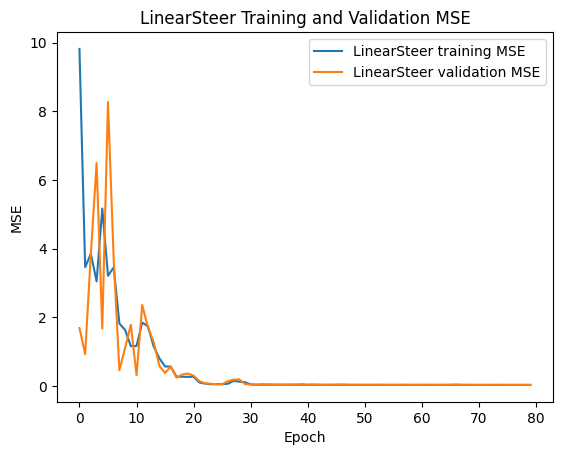

In [ ]:

# Train and evaluate the flattened-image linear-regression baseline
linearsteer_model = LinearSteer(width=img_size[1], height=img_size[0]).to(device)

linearsteer_train_losses, linearsteer_val_losses = stir_train(
    linearsteer_model,
    batch_size=256,
    learning_rate=0.001,
    num_epochs=80,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
    model_name="LinearSteer",
    checkpoint_stem="linearsteer",
)

linearsteer_metrics = evaluate_steering_model(
    linearsteer_model,
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
)

print(
    "LinearSteer trainable parameters:",
    sum(parameter.numel() for parameter in linearsteer_model.parameters()
        if parameter.requires_grad),
)

plt.plot(linearsteer_train_losses, label="LinearSteer training MSE")
plt.plot(linearsteer_val_losses, label="LinearSteer validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("LinearSteer Training and Validation MSE")
plt.legend()
plt.show()


In [41]:
linearsteer_accuracy = steering_accuracy_report(
    linearsteer_model,
    model_name="LinearSteer baseline",
    batch_size=256,
    image_size=img_size,
    frame_stride=STEERING_FRAME_STRIDE,
    input_mode=STEERING_INPUT_MODE,
    num_workers=2,
    use_amp=True,
)

Steering samples: train=15,136, validation=3,243, test=3,244; input_mode=roi; image_size=(110, 220); frame_stride=4; uint8 cache=True

LinearSteer baseline test-set performance
---------------------------------------------
Test samples:              3,244
MSE:                       0.007433
RMSE:                      0.086218
MAE:                       0.045357
R²:                        0.1116
Accuracy within ±0.05:     79.16%
Accuracy within ±0.10:     90.66%


In [ ]:
# Compare the CNN against the flattened-image linear baseline
comparison = pd.DataFrame(
    [
        {
            "model": "NavisSteer CNN",
            "parameters": sum(
                parameter.numel()
                for parameter in navissteer_model.parameters()
                if parameter.requires_grad
            ),
            **navissteer_metrics,
        },
        {
            "model": "LinearSteer baseline",
            "parameters": sum(
                parameter.numel()
                for parameter in linearsteer_model.parameters()
                if parameter.requires_grad
            ),
            **linearsteer_metrics,
        },
    ]
)

display(comparison)

plt.figure(figsize=(8, 5))
plt.plot(navissteer_val_losses, marker="o", label="NavisSteer validation MSE")
plt.plot(linearsteer_val_losses, marker="o", label="LinearSteer validation MSE")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("NavisSteer vs Linear Regression Baseline")
plt.grid(alpha=0.25)
plt.legend()
plt.show()
